In [109]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [110]:
binned    = np.load('../Code/NWB/spikes.npy',allow_pickle=True)
subj_sep  = np.load('../Code/NWB/subjs_sep.npy',allow_pickle=True)
units     = np.load('../Code/NWB/units.npy',allow_pickle=True)

In [111]:
len(binned)

28

In [112]:
len(subj_sep)

28

In [265]:
mask = [subj_sep[i][0]==53 for i in range(len(subj_sep))]

In [266]:
units[mask][2][0]

array(['uAHL2_0', 'uAHL2_1', 'uAHL4_0', 'uAHL4_4', 'uAHL5_0', 'uAHL5_12',
       'uAHL5_2', 'uAHL6_1', 'uAL2_1', 'uAR2_3', 'uAR3_1', 'uAR6_0',
       'uAR6_1', 'uAR6_2', 'uAR7_0', 'uPHL1_0', 'uPHL1_1', 'uPHL1_4',
       'uPHL5_0', 'uPHL5_1', 'uPHL8_0', 'uPHR7_0', 'uPHR7_1', 'uPHR7_2',
       'uPHR7_4', 'uPHR7_5'], dtype=object)

In [267]:
units[mask][2][0][4]

'uAHL5_0'

In [308]:
maskU = units[mask][2][0]==units[mask][2][0][-9]
np.sum(maskU)

1

In [309]:
raster = binned[mask][1]
len(raster)

63

In [310]:
unit_spike = [np.array(r,dtype=object)[np.where(maskU)[0]][0] for r in raster]

In [311]:
len(unit_spike)

63

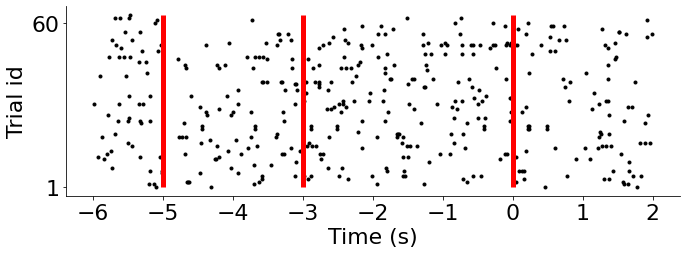

In [312]:
fig,ax = plt.subplots(figsize=(10,4))

plt.rcParams.update({'font.size': 22})
for i in range(len(unit_spike)):
    plt.scatter(unit_spike[i]-6,[i+1]*len(unit_spike[i]),marker='.',color='k')
plt.vlines([-5,-3,0],1,len(unit_spike),color='red',linewidth=5)
plt.xlabel('Time (s)')
plt.ylabel('Trial id')
plt.yticks([1,60])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('spikeOut2.png',dpi=200)
plt.show()